C:\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.7907 - loss: 0.6184 - val_accuracy: 0.8674 - val_loss: 0.5023
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8881 - loss: 0.3841 - val_accuracy: 0.8881 - val_loss: 0.3154
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9137 - loss: 0.2520 - val_accuracy: 0.8957 - val_loss: 0.2625
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9301 - loss: 0.1997 - val_accuracy: 0.8961 - val_loss: 0.2526
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9402 - loss: 0.1708 - val_accuracy: 0.8960 - val_loss: 0.2524
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9476 - loss: 0.1516 - val_accuracy: 0.8932 - val_loss: 0.2605
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9553 - loss: 0.1342 - val_accuracy: 0.8921 - val_loss: 0.2727
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9603 - loss: 0.1212 - val_accuracy: 0.8878 - v

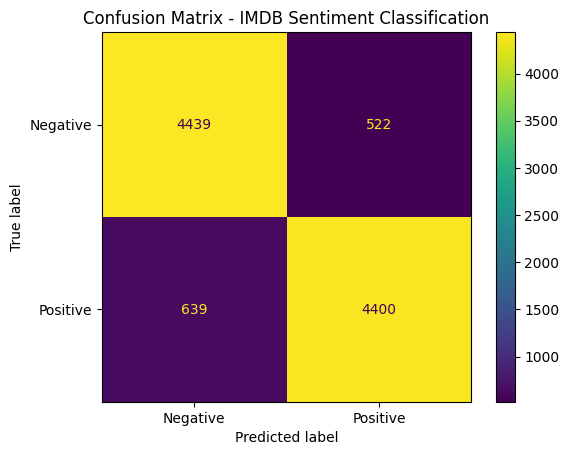

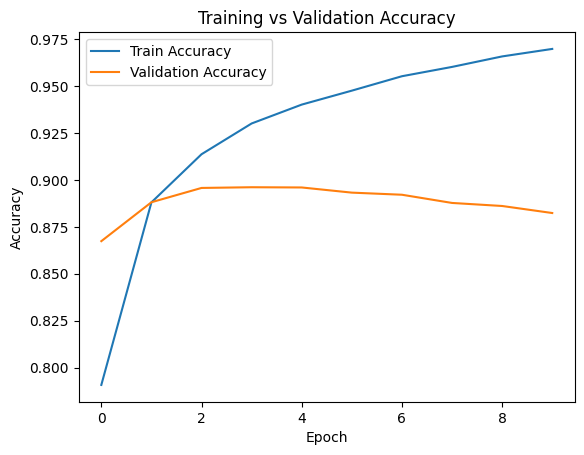

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Load dataset
df = pd.read_csv("IMDB Dataset.csv")   # make sure filename matches

# 2. Features and labels
X = df['review']
y = df['sentiment']

# 3. Encode labels
y = y.map({'positive': 1, 'negative': 0}).values

# 4. TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=10000)
X = vectorizer.fit_transform(X).toarray()

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. Build model
model = Sequential([
    Dense(16, activation='relu', input_shape=(10000,)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 7. Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 8. Train
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=512,
    validation_split=0.2
)

# 9. Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

# 10. Predictions
predictions = model.predict(X_test)
predicted_labels = (predictions > 0.5).astype(int).reshape(-1)

# 11. Show sample predictions
print("\nSample Predictions:")
for i in range(5):
    pred = "Positive" if predictions[i] == 1 else "Negative"
    actual = "Positive" if y_test[i] == 1 else "Negative"
    print(f"{i+1}. Predicted: {pred} | Actual: {actual}")

# 12. Confusion Matrix
cm = confusion_matrix(y_test, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Negative", "Positive"])
disp.plot()
plt.title("Confusion Matrix - IMDB Sentiment Classification")
plt.show()
